In [1]:
%pip install pandas geopandas matplotlib geodatasets scikit-learn duckdb numpy geopy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install "numpy<2" --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geodatasets
from geodatasets import get_path
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import duckdb
import math
from sklearn.cluster import HDBSCAN
import numpy as np
from geopy.distance import geodesic
from matplotlib.lines import Line2D



from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import haversine_distances



# ---------------------------------------------------------
# 📂 GLOBAL PATHS - DO NOT CHANGE THESE
# ---------------------------------------------------------
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"
CSV_PATH = BASE_PATH / "csv-files" / "may-2025"

print(f"✅ Data Directories Set:\n  - Parquet: {PARQUET_PATH}\n  - CSV: {CSV_PATH}")

✅ Data Directories Set:
  - Parquet: /data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025
  - CSV: /data/shared/OpenAlex/processed-snapshots/csv-files/may-2025


In [2]:
# Connect to duckdb
con = duckdb.connect()
# Limit memory usage
con.execute("SET memory_limit = '6GB'")
# Disable progress bars to avoid exceeding message limit
con.execute("SET enable_progress_bar = false")
con.execute("SET enable_progress_bar_print = false")

In [3]:
# Table paths
works_path = PARQUET_PATH / "works"
topics_path = PARQUET_PATH / "works_topics"
works_references_works_path = PARQUET_PATH / "works_referenced_works"
authorships_path = PARQUET_PATH / "works_authorships"
primary_location_path = PARQUET_PATH / "works_primary_location"
work_grants_path = PARQUET_PATH / "works_grants"
institutions_file = CSV_PATH / "institutions.csv.gz"
institutions_geo_file = CSV_PATH / "institutions_geo.csv.gz"
funders_file = CSV_PATH / "funders.csv.gz"
sources_file = CSV_PATH / "sources.csv.gz"

In [25]:
machine_learning_topics = {
    10057: "Face and Expression Recognition",
    10538: "Data Mining Algorithms and Applications",
    10682: "Quantum Computing Algorithms and Architecture",
    10824: "Image Retrieval and Classification Techniques",
    11689: "Adversarial Robustness in Machine Learning",
    11714: "Multimodal Machine Learning Applications",
    12072: "Machine Learning and Algorithms",
    12535: "Machine Learning and Data Classification",
    12676: "Machine Learning and ELM",
    13702: "Machine Learning in Healthcare"
}
topic_ids = [10057, 10538, 10682, 10824, 11689, 11714, 12072, 12535, 12676, 13702]

## Do machine learning topics have a global spread through physical proximity or institutional networks?
We have refined our initial question on how topics spread globally to focus on how Machine Learning spreads, either by physical proximity or through institutional networks. With the ease that the internet provides to share information around the globe instantly, does the research spread from one research hub to its neighboring hubs, or does it spread through networks such as Stanford to MIT to Oxford?

### Creating DuckDB tables
To limit the number of works, and to keep memory usage low, 
1) the works_topics table is created with the following machine learning topics: 
* 12676: "Machine Learning and ELM"
* 12072: "Machine Learning and Algorithms"
* 12535: "Machine Learning and Data Classification"
* 13702: "Machine Learning in Healthcare"
* 11689: "Adversarial Robustness in Machine Learning"

Since the works_topics table also contains the work_ids and publication_year, the works in this table are limited to those published between 2010 and 2019 to further reduce the size of the table to a single decade of works.

2) The works table was created by selecting the works with work_ids from the works_topics table. To reduce the number of tables and joins needed, the institution_id of the first author for each work is taken from the authorship parquet file and added as a column in the works table. The works are further filtered to works that have been cited more than 50 times and the institution_id must not be null.

3) The institutions_geo table is created by selecting the institution_ids from the works table. The institutions file has been left out entirely since the institutions geo file contains all the relevant columns we need.

In [26]:
# Create the topics tables within the topics of Machine Learning with works published between 2010 and 2020
con.execute(f"""
    CREATE OR REPLACE TABLE works_topics AS 
    SELECT 
        work_id, 
        topic_id,  
        subfield_id
    FROM read_parquet('{topics_path}/**/*.parquet')
    WHERE topic_id in (10057, 10538, 10682, 10824, 11689, 11714, 12072, 12535, 12676, 13702) AND publication_year >= 2010 AND publication_year <=2019
""")
print("✅ Created topics")

# Create the works table and include the institution_id from the authorships table
con.execute(f"""
    CREATE OR REPLACE TABLE works AS 
    WITH filtered_ids AS (
        SELECT DISTINCT work_id FROM works_topics
    ),
    primary_authorship AS (
        SELECT work_id, institution_id
        FROM read_parquet('{authorships_path}/**/*.parquet')
        WHERE author_position = 'first'
    )
    SELECT 
        w.work_id, 
        w.publication_year, 
        w.cited_by_count,
        a.institution_id
    FROM read_parquet('{works_path}/**/*.parquet') w
    INNER JOIN filtered_ids f ON w.work_id = f.work_id
    LEFT JOIN primary_authorship a ON w.work_id = a.work_id
    WHERE w.cited_by_count > 50 AND a.institution_id IS NOT NULL
""")
print("✅ Created works with institution_id")

# Create the institutions_geo table
con.execute(f"""
    CREATE OR REPLACE TABLE institutions_geo AS 
    SELECT 
        i.institution_id, 
        i.geonames_city_id, 
        i.city,
        i.country_code, 
        i.latitude, 
        i.longitude 
    FROM read_csv_auto('{institutions_geo_file}') i
    JOIN (SELECT DISTINCT institution_id FROM works) w ON w.institution_id = i.institution_id
""")
print("✅ Created institutions_geo")

✅ Created topics
✅ Created works with institution_id
✅ Created institutions_geo


### Finding Research hubs
To find the research hubs, we first created a dataframe of the institutions and convert their latitude and longitude into radians since we are looking at points on a sphere. 

After calculating k-means and the silhouette score, the optimal number of clusters was determined to be 3, which represents entire continents. This does not help us track the spread of topics since we want smaller, precise clusters. K-means is also grouping institutions that might not be considered part of a research hub since k-means includes noise points.

In [27]:
# Getting the latitude and longitude for the institutions and convert to radians
query = f"""
        SELECT institution_id, city, latitude, longitude 
        FROM institutions_geo
    """
institutions = con.execute(query).df()
institutions['rlatitude'] = institutions['latitude'] * (math.pi / 180)
institutions['rlongitude'] = institutions['longitude'] * (math.pi / 180)

institution_radians = institutions[['rlatitude', 'rlongitude']].values

In [31]:
K_range_e = range(2, 20)
inertia_e = []
s_scores_e = []

# Looping through to get the elbow and silhouette
for k in K_range_e:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(institution_radians)
    
    inertia_e.append(kmeans.inertia_)
    s_scores_e.append(silhouette_score(institution_radians, labels))
print("✅ Finished k-means Euclidean")

✅ Finished k-means Euclidean


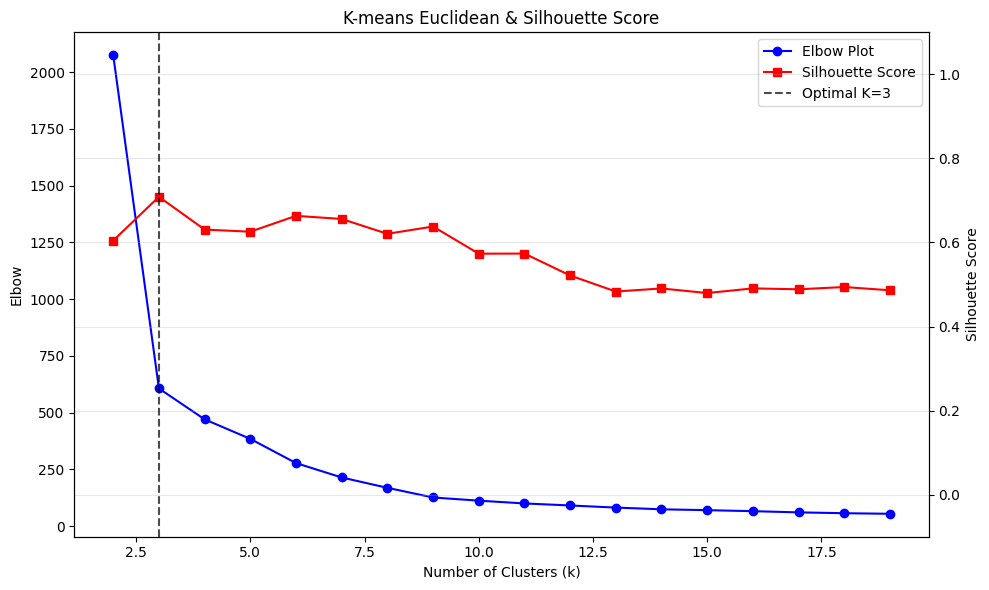

In [32]:
# Plotting the data
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Elbow')
line1, = ax1.plot(K_range_e, inertia_e, marker='o', color='blue', label='Elbow Plot')
ax1.tick_params(axis='y')

ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score')
line2, = ax2.plot(K_range_e, s_scores_e, marker='s', color='red', label='Silhouette Score')
ax2.tick_params(axis='y')
ax2.set_ylim(-0.1, 1.1)

optimal_k = plt.axvline(x=3, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Optimal K=3')

lines = [line1, line2, optimal_k]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('K-means Euclidean & Silhouette Score')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [33]:
K_range_h = range(2, 20)
inertia_h = []
s_scores_h = []

for k in K_range_h:
    kmedoids = KMedoids(n_clusters=k, metric='haversine', method='pam', random_state=42)
    kmedoids.fit(institution_radians)
    
    inertia_h.append(kmedoids.inertia_)
    s_scores_h.append(silhouette_score(institution_radians, kmedoids.labels_))
print("✅ Finished k-means haversine")

✅ Finished k-means haversine


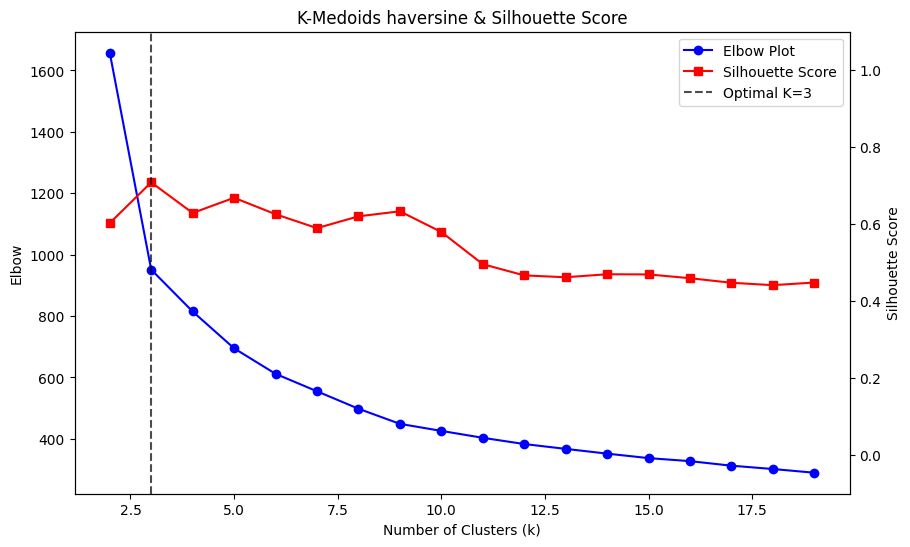

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Elbow')
line1, = ax1.plot(K_range_h, inertia_h, marker='o', color='blue', label='Elbow Plot')
ax1.tick_params(axis='y')

ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score')
line2, = ax2.plot(K_range_h, s_scores_h, marker='s', color='red', label='Silhouette Score')
ax2.tick_params(axis='y')
ax2.set_ylim(-0.1, 1.1)

optimal_k = plt.axvline(x=3, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Optimal K=3')

lines = [line1, line2, optimal_k]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('K-Medoids haversine & Silhouette Score')
plt.savefig(f"kmeans-haversine.png", dpi=300)
plt.show()

After running DBSCAN, we are given 76 research hubs, which will be much more useful to track the spread of topics. There are 818 institutions that do not belong to any research hubs, but may still be researching and publishing works on machine learning topics.

The research clusters are named by the city with the most institutions within the research cluster, not the city that is at the centroid of the hub.

The centroids for each research hub a calculated by taking the mean latitude and longitude of all the institutions in the cluster.

In [28]:
# Run DBSCAN
model = HDBSCAN(min_cluster_size=10, metric='haversine', cluster_selection_method='eom', copy=True)
institutions['dbscan_cluster'] = model.fit_predict(institution_radians)

# Find the hub names
hub_names = institutions[institutions['dbscan_cluster'] != -1].groupby('dbscan_cluster')['city'].agg(lambda x: x.value_counts().index[0])

num_hubs = len(institutions[institutions['dbscan_cluster'] != -1]['dbscan_cluster'].unique())
noise_count = len(institutions[institutions['dbscan_cluster'] == -1])
print(f"Found {num_hubs} dense research hubs and {noise_count} noise institutions")

# Find the centroids
hub_centroids = institutions.groupby('dbscan_cluster')[['latitude', 'longitude']].mean().reset_index()

Found 132 dense research hubs and 1336 noise institutions


## Counting number of works per research hub by year
1) Count how many works each institution published each year for a topic.
2) Merge the results with the research hub data and group by research hub. 
3) Save each year and its counts in a dictionary to easily access later.

In [29]:
def get_year_counts(topic_id):
    all_years_data = []
    
    for year in range(2010, 2020):
        yearly_query = f"""
            SELECT w.institution_id, count(distinct w.work_id) as num_works
            FROM works_topics t
            JOIN works w ON w.work_id = t.work_id
            WHERE w.publication_year = {year} AND t.topic_id = {topic_id}
            GROUP BY w.institution_id
        """
        
        # Get SQL results
        results = con.execute(yearly_query).df()
        if len(results) != 0:
            # Merge with cluster map
            merged = results.merge(institutions[['institution_id', 'dbscan_cluster']], on='institution_id')
            # Sum by Hub
            counts = merged.groupby('dbscan_cluster')['num_works'].sum().reset_index()
            data_for_year = (year, counts)
            all_years_data.append(data_for_year)
    return all_years_data

## Finding the weighted center for the topic for each year
To see how the topic spreads over the years, we use Spatio-Temporal Centroid Tracking to calculate the weighted center of all the research hubs based on the number of works each hub published that year. We loop through the entire decade and calculate the distance the weighted center moved from the previous year.

In [30]:
def calculate_research_topic_center(year_counts_df):
    # Merge the hub counts with their geographic centers
    geo_data = year_counts_df.merge(hub_centroids, on='dbscan_cluster')
    # Calculate the weighted average latitude and longitude
    weights = geo_data['num_works']
    avg_lat = np.average(geo_data['latitude'], weights=weights)
    avg_lon = np.average(geo_data['longitude'], weights=weights)
    return avg_lat, avg_lon

In [31]:
def plot_yearly_difference(topic_df):
    # Filter out the first year since the distance is 0
    plot_data = topic_df.iloc[1:]
    plt.figure(figsize=(12, 6))
    
    # Plot the distance jumps
    plt.plot(plot_data['year'], plot_data['distance'], 
             marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8)
    
    # Professional formatting for your report
    plt.title(f'{machine_learning_topics[topic_id]}: Annual distance of Research Center', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Jump Distance (km)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(plot_data['year'])
    plt.show()

In [32]:
def calc_center_diff_from_prev_year(prev_year_center, curr_year_center, year, first):
    year_row = {}
    year_row['year'] = year
    year_row['latitude'] = curr_year_center[0]
    year_row['longitude'] = curr_year_center[1]
    if first:
        year_row['distance'] = 0
    else:
        year_row['distance'] = geodesic(curr_year_center, prev_year_center).km
    return year_row
    
    

## Putting it all together
For each machine learning topic:
1) Get the counts of works published by each research hub within the decade
2) Calculate the weighted centers for each year and calulate the distance from the previous year
3) Plot the distances

Also creating a master dict that for each year creates a list of the topics with the following stats:
* The weighted center of the topic
* The number of research hubs that published works on the topic
* The total number of works published for the topic




Face and Expression Recognition
2010 - 576 works in 90 hubs
2011 - 678 works in 106 hubs
2012 - 646 works in 95 hubs
2013 - 596 works in 92 hubs
2014 - 572 works in 98 hubs
2015 - 721 works in 95 hubs
2016 - 647 works in 87 hubs
2017 - 786 works in 103 hubs
2018 - 619 works in 88 hubs
2019 - 602 works in 88 hubs


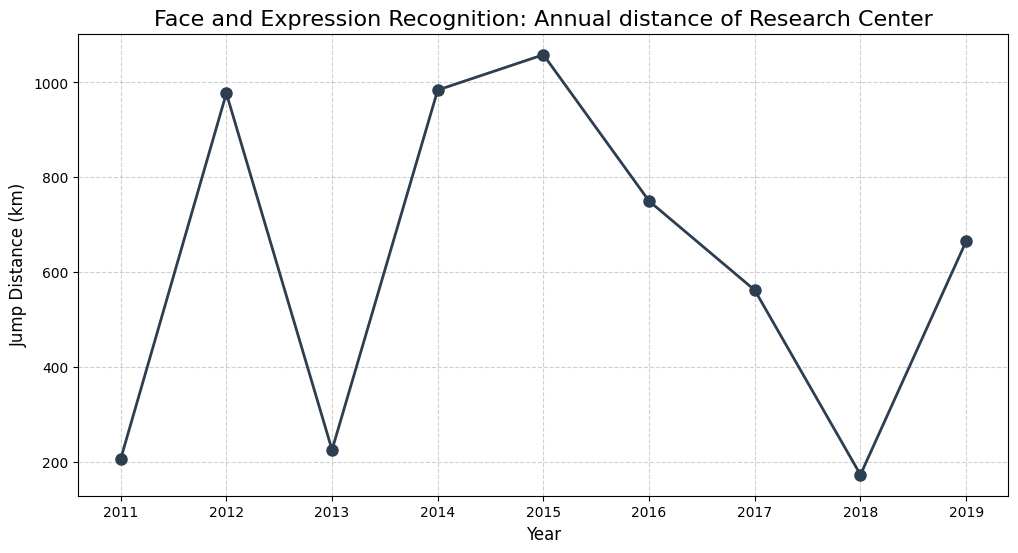




Data Mining Algorithms and Applications
2010 - 342 works in 87 hubs
2011 - 327 works in 84 hubs
2012 - 341 works in 82 hubs
2013 - 274 works in 83 hubs
2014 - 288 works in 85 hubs
2015 - 270 works in 81 hubs
2016 - 263 works in 73 hubs
2017 - 225 works in 72 hubs
2018 - 213 works in 73 hubs
2019 - 189 works in 56 hubs


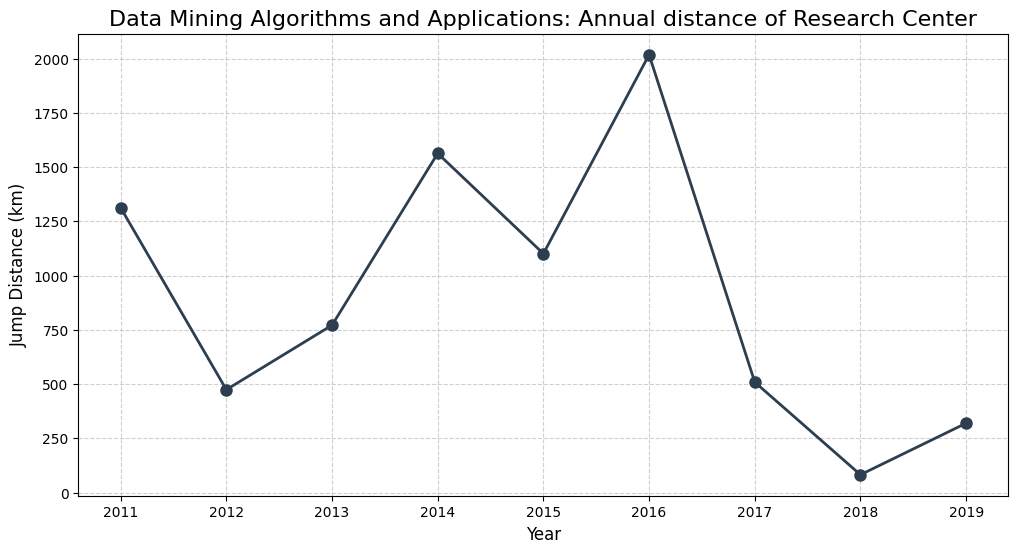




Quantum Computing Algorithms and Architecture
2010 - 569 works in 77 hubs
2011 - 589 works in 79 hubs
2012 - 709 works in 82 hubs
2013 - 646 works in 91 hubs
2014 - 710 works in 87 hubs
2015 - 682 works in 89 hubs
2016 - 695 works in 84 hubs
2017 - 775 works in 86 hubs
2018 - 811 works in 91 hubs
2019 - 918 works in 84 hubs


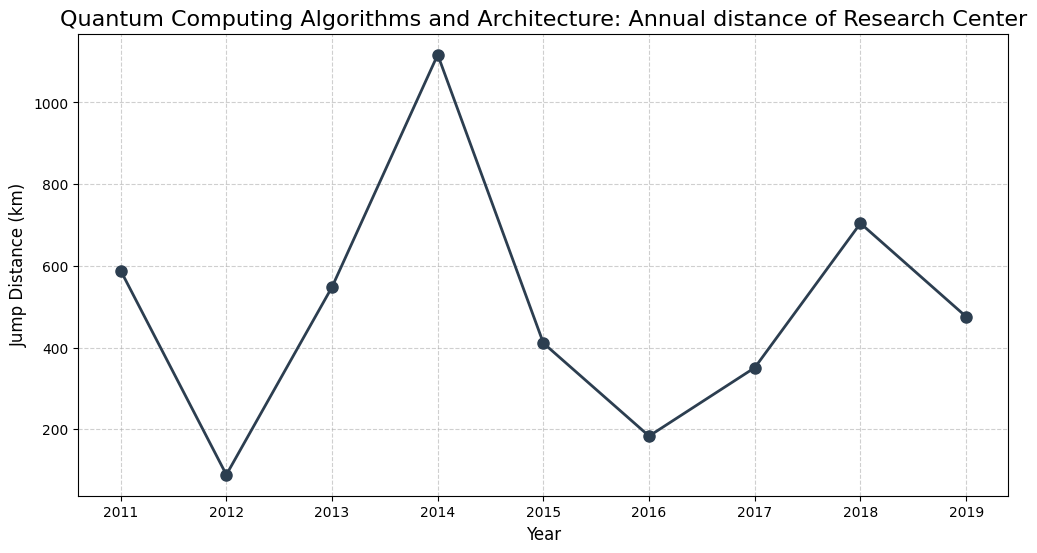




Image Retrieval and Classification Techniques
2010 - 625 works in 98 hubs
2011 - 612 works in 100 hubs
2012 - 591 works in 98 hubs
2013 - 555 works in 99 hubs
2014 - 564 works in 101 hubs
2015 - 540 works in 93 hubs
2016 - 563 works in 92 hubs
2017 - 490 works in 84 hubs
2018 - 355 works in 76 hubs
2019 - 369 works in 73 hubs


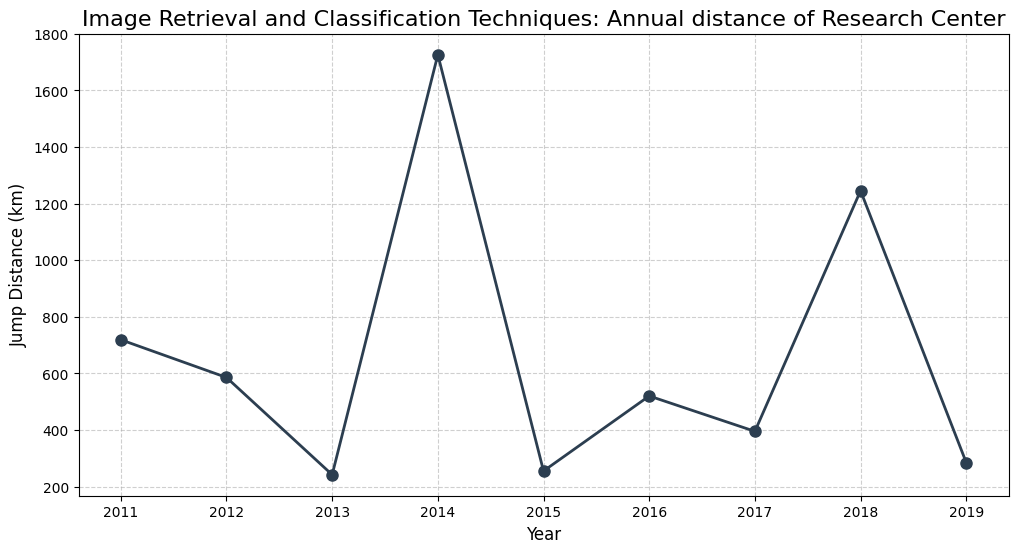




Adversarial Robustness in Machine Learning
2010 - 28 works in 12 hubs
2011 - 27 works in 15 hubs
2012 - 35 works in 16 hubs
2013 - 51 works in 23 hubs
2014 - 54 works in 22 hubs
2015 - 106 works in 37 hubs
2016 - 213 works in 45 hubs
2017 - 384 works in 59 hubs
2018 - 680 works in 80 hubs
2019 - 849 works in 95 hubs


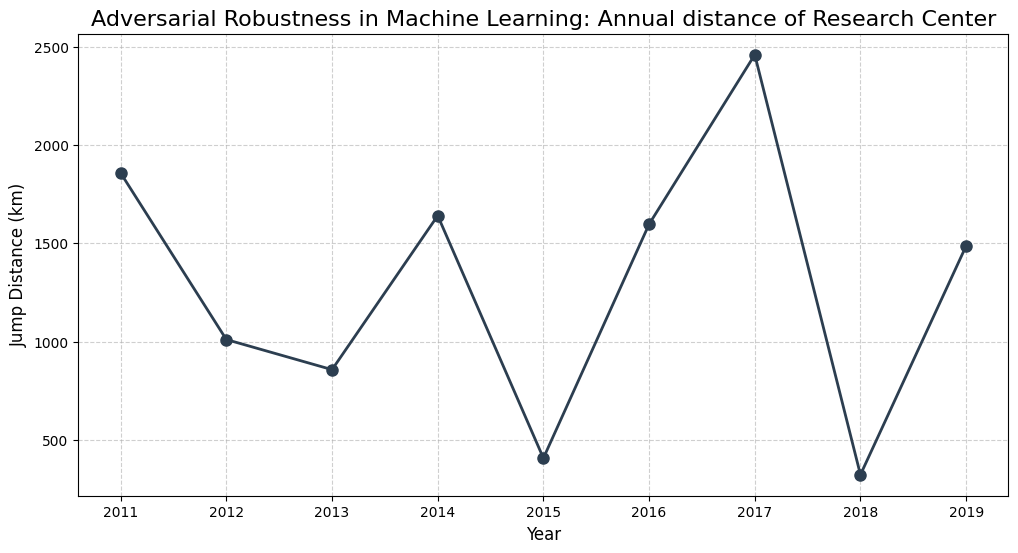




Multimodal Machine Learning Applications
2010 - 107 works in 37 hubs
2011 - 122 works in 33 hubs
2012 - 102 works in 40 hubs
2013 - 199 works in 52 hubs
2014 - 263 works in 54 hubs
2015 - 420 works in 64 hubs
2016 - 623 works in 80 hubs
2017 - 931 works in 85 hubs
2018 - 1101 works in 95 hubs
2019 - 1363 works in 96 hubs


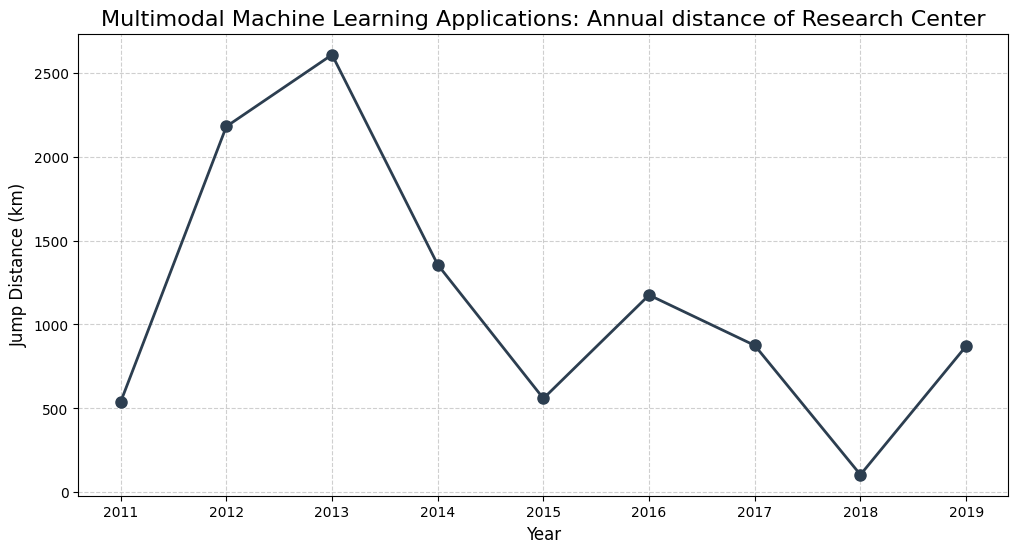




Machine Learning and Algorithms
2010 - 301 works in 67 hubs
2011 - 304 works in 58 hubs
2012 - 284 works in 58 hubs
2013 - 330 works in 74 hubs
2014 - 240 works in 59 hubs
2015 - 303 works in 59 hubs
2016 - 235 works in 61 hubs
2017 - 283 works in 59 hubs
2018 - 258 works in 62 hubs
2019 - 262 works in 66 hubs


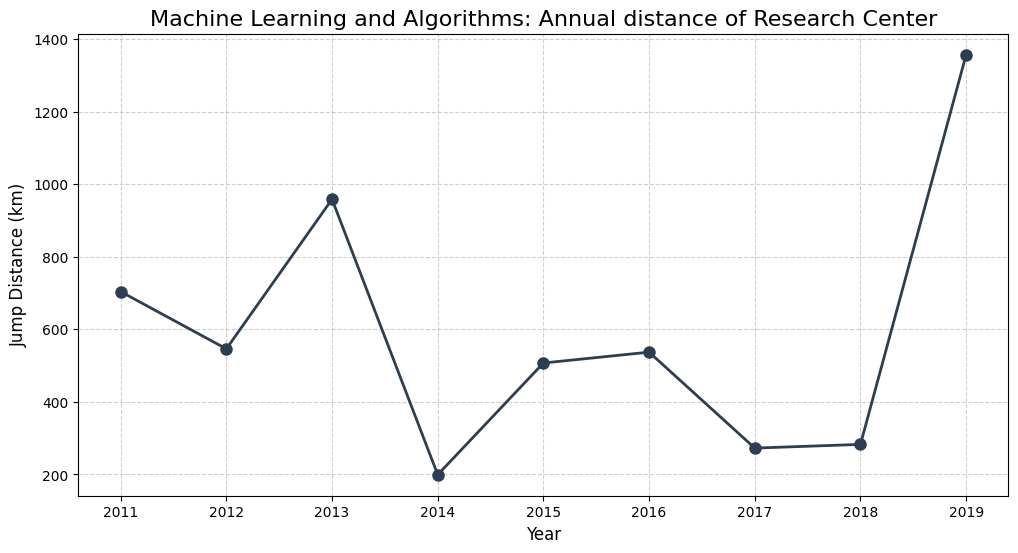




Machine Learning and Data Classification
2010 - 194 works in 56 hubs
2011 - 206 works in 67 hubs
2012 - 191 works in 59 hubs
2013 - 227 works in 64 hubs
2014 - 227 works in 64 hubs
2015 - 326 works in 79 hubs
2016 - 348 works in 87 hubs
2017 - 403 works in 79 hubs
2018 - 431 works in 85 hubs
2019 - 520 works in 105 hubs


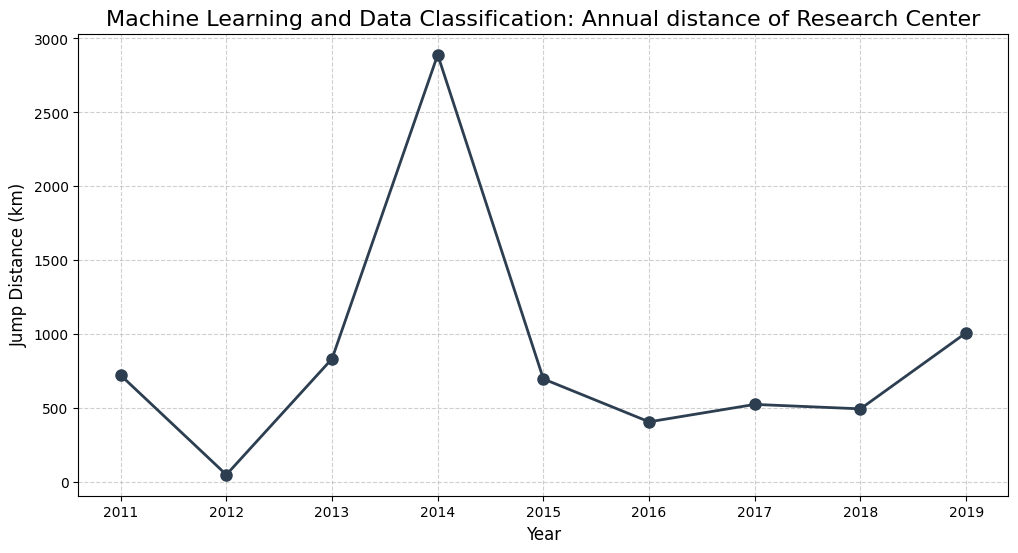




Machine Learning and ELM
2010 - 76 works in 28 hubs
2011 - 124 works in 42 hubs
2012 - 135 works in 46 hubs
2013 - 191 works in 46 hubs
2014 - 182 works in 57 hubs
2015 - 274 works in 64 hubs
2016 - 260 works in 66 hubs
2017 - 389 works in 78 hubs
2018 - 404 works in 79 hubs
2019 - 472 works in 85 hubs


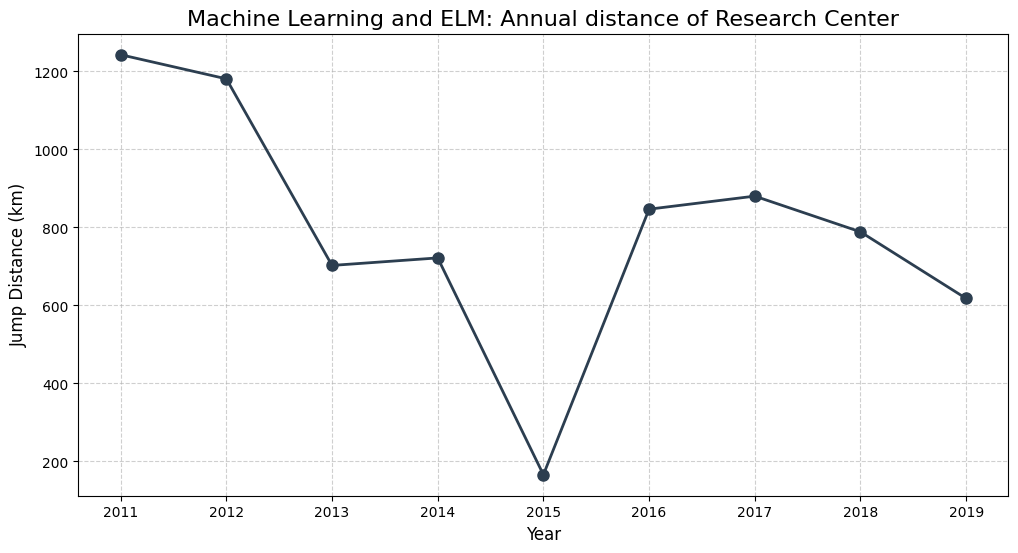




Machine Learning in Healthcare
2010 - 42 works in 20 hubs
2011 - 61 works in 30 hubs
2012 - 64 works in 25 hubs
2013 - 95 works in 30 hubs
2014 - 126 works in 47 hubs
2015 - 154 works in 43 hubs
2016 - 217 works in 54 hubs
2017 - 244 works in 61 hubs
2018 - 385 works in 72 hubs
2019 - 626 works in 94 hubs


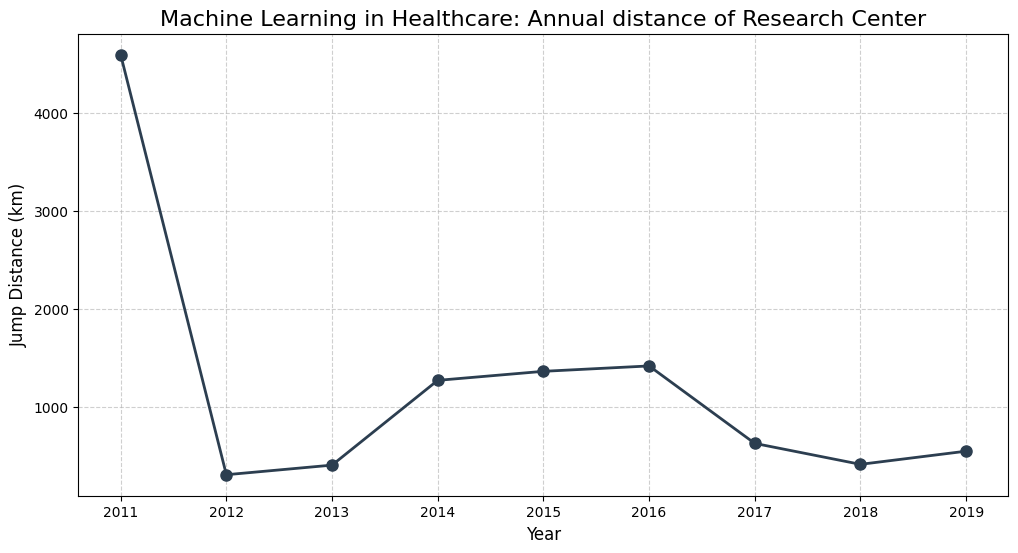

In [33]:
# Create a master dict that store all the topic centers by year
all_topics_all_year_centers = {}
for topic_id in machine_learning_topics:
    print("\n\n")
    print("=" * 50)
    print(machine_learning_topics[topic_id])
    print("=" * 50)
    all_years_data = get_year_counts(topic_id)
    annual_distance_data = []
    previous_year = (0,0)
    for index, year_tupple in enumerate(all_years_data):
        year = year_tupple[0]
        year_df = year_tupple[1]
        total_num_works = year_df['num_works'].sum()
        num_hubs = len(year_df['dbscan_cluster'].tolist())
       # Find the weighted center of the research
        year_weigthed_center = calculate_research_topic_center(year_tupple[1])
        # Calculate distance from last year center
        if index == 0:
            annual_distance_data.append(calc_center_diff_from_prev_year(previous_year, year_weigthed_center, year, True))
        else:
            annual_distance_data.append(calc_center_diff_from_prev_year(previous_year, year_weigthed_center, year, False))

        # Add the topic's center, num_hubs, and total_num_works to the master dict
        if year not in all_topics_all_year_centers:
            all_topics_all_year_centers[year] = []
        year_list = all_topics_all_year_centers[year]
        year_obj = (topic_id, year_weigthed_center[0], year_weigthed_center[1], num_hubs, total_num_works)
        print(f"{year} - {total_num_works} works in {num_hubs} hubs")
        year_list.append(year_obj)
        all_topics_all_year_centers[year] = year_list

        previous_year = year_weigthed_center
        
    # Create a dataframe for plotting
    df_yearly_centers = pd.DataFrame(annual_distance_data)
    # Plot the distances by year for the topic
    plot_yearly_difference(df_yearly_centers)

In [34]:
def plot_topics_centers_for_year(centers_map_df):
    fig, ax = plt.subplots(figsize=(15, 8))
    # Add map background
    world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
    world.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0') 
    # Plot points
    ax.scatter(
        centers_map_df['centroid_long'], 
        centers_map_df['centroid_lat'], 
        c=centers_map_df['color'],
        s=centers_map_df['num_hubs'] * 25,
        alpha=0.8, 
        edgecolor='black', 
        linewidth=0.7,
        zorder=3
    )
    
    # Add Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'{machine_learning_topics[tid]}',
               markerfacecolor=topic_colors[tid], markersize=10)
        for tid in sorted(centers_map_df['topic_id'].unique())
    ]
    ax.legend(handles=legend_elements, loc='lower left', title="Topics", frameon=True)

    plt.title(f"Topic weighted centers - {year}", fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    plt.savefig(f"map_{year}.png", dpi=300)
    plt.show()

In 2010:
	Face and Expression Recognition had 576 works published by 90 research hubs
	Data Mining Algorithms and Applications had 342 works published by 87 research hubs
	Quantum Computing Algorithms and Architecture had 569 works published by 77 research hubs
	Image Retrieval and Classification Techniques had 625 works published by 98 research hubs
	Adversarial Robustness in Machine Learning had 28 works published by 12 research hubs
	Multimodal Machine Learning Applications had 107 works published by 37 research hubs
	Machine Learning and Algorithms had 301 works published by 67 research hubs
	Machine Learning and Data Classification had 194 works published by 56 research hubs
	Machine Learning and ELM had 76 works published by 28 research hubs
	Machine Learning in Healthcare had 42 works published by 20 research hubs


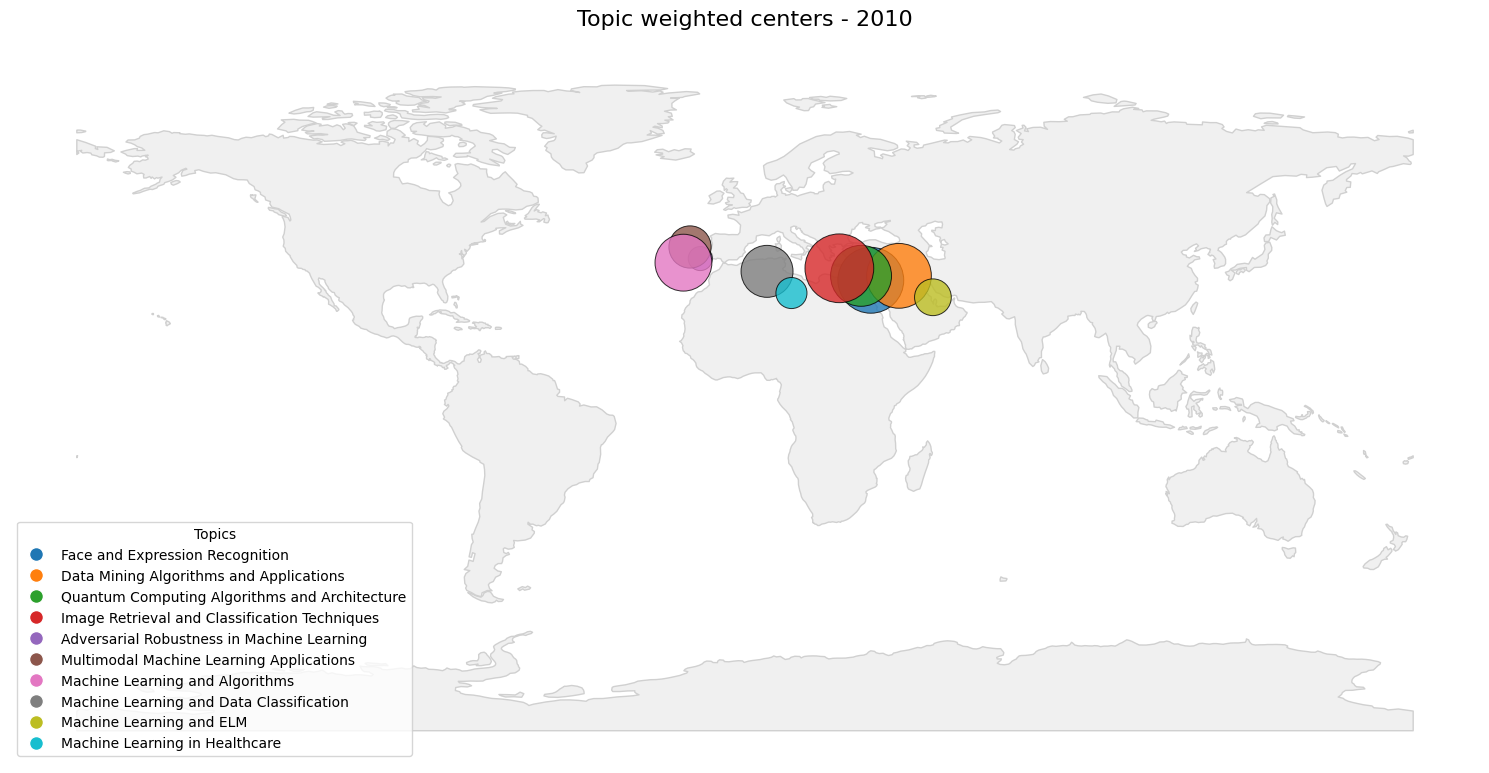

In 2011:
	Face and Expression Recognition had 678 works published by 106 research hubs
	Data Mining Algorithms and Applications had 327 works published by 84 research hubs
	Quantum Computing Algorithms and Architecture had 589 works published by 79 research hubs
	Image Retrieval and Classification Techniques had 612 works published by 100 research hubs
	Adversarial Robustness in Machine Learning had 27 works published by 15 research hubs
	Multimodal Machine Learning Applications had 122 works published by 33 research hubs
	Machine Learning and Algorithms had 304 works published by 58 research hubs
	Machine Learning and Data Classification had 206 works published by 67 research hubs
	Machine Learning and ELM had 124 works published by 42 research hubs
	Machine Learning in Healthcare had 61 works published by 30 research hubs


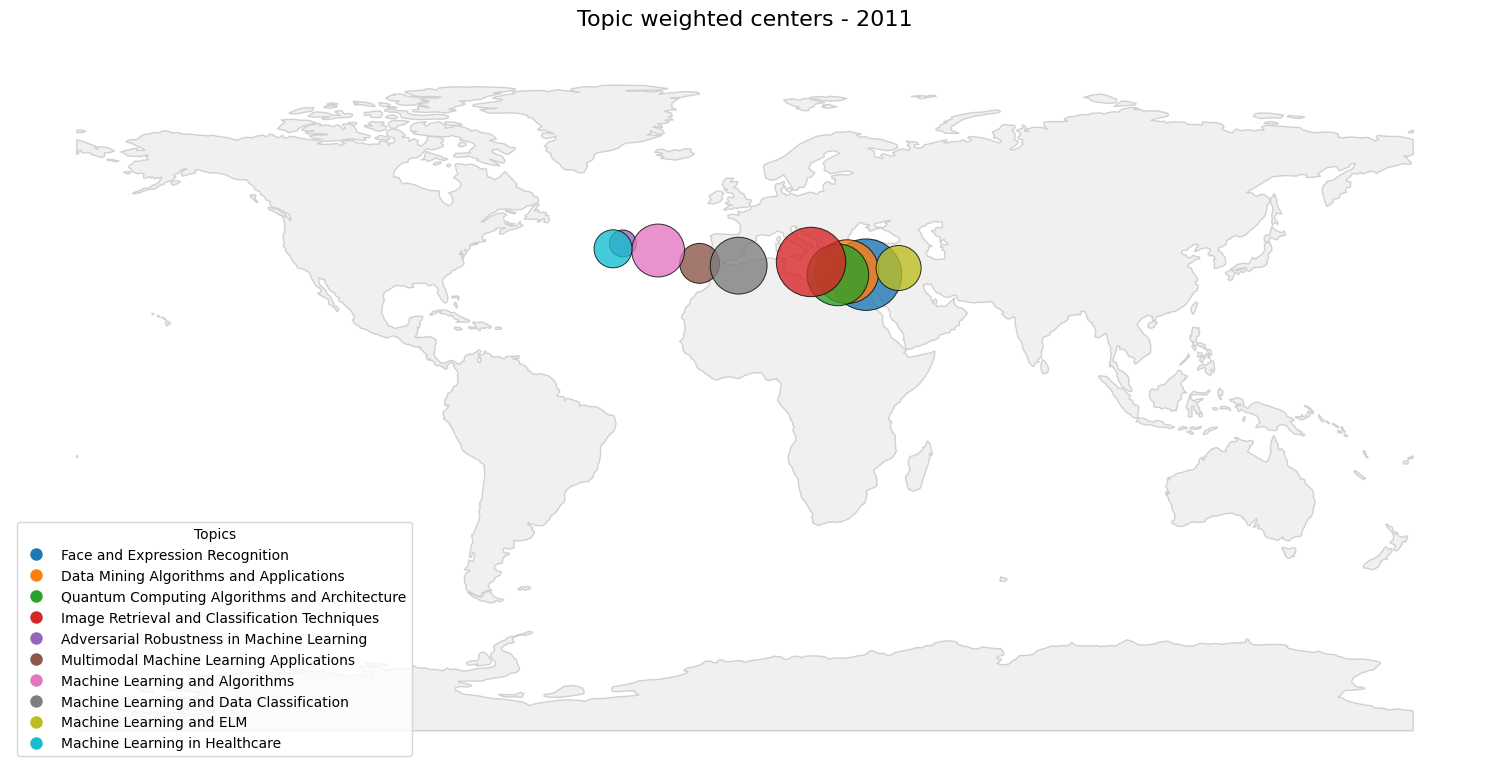

In 2012:
	Face and Expression Recognition had 646 works published by 95 research hubs
	Data Mining Algorithms and Applications had 341 works published by 82 research hubs
	Quantum Computing Algorithms and Architecture had 709 works published by 82 research hubs
	Image Retrieval and Classification Techniques had 591 works published by 98 research hubs
	Adversarial Robustness in Machine Learning had 35 works published by 16 research hubs
	Multimodal Machine Learning Applications had 102 works published by 40 research hubs
	Machine Learning and Algorithms had 284 works published by 58 research hubs
	Machine Learning and Data Classification had 191 works published by 59 research hubs
	Machine Learning and ELM had 135 works published by 46 research hubs
	Machine Learning in Healthcare had 64 works published by 25 research hubs


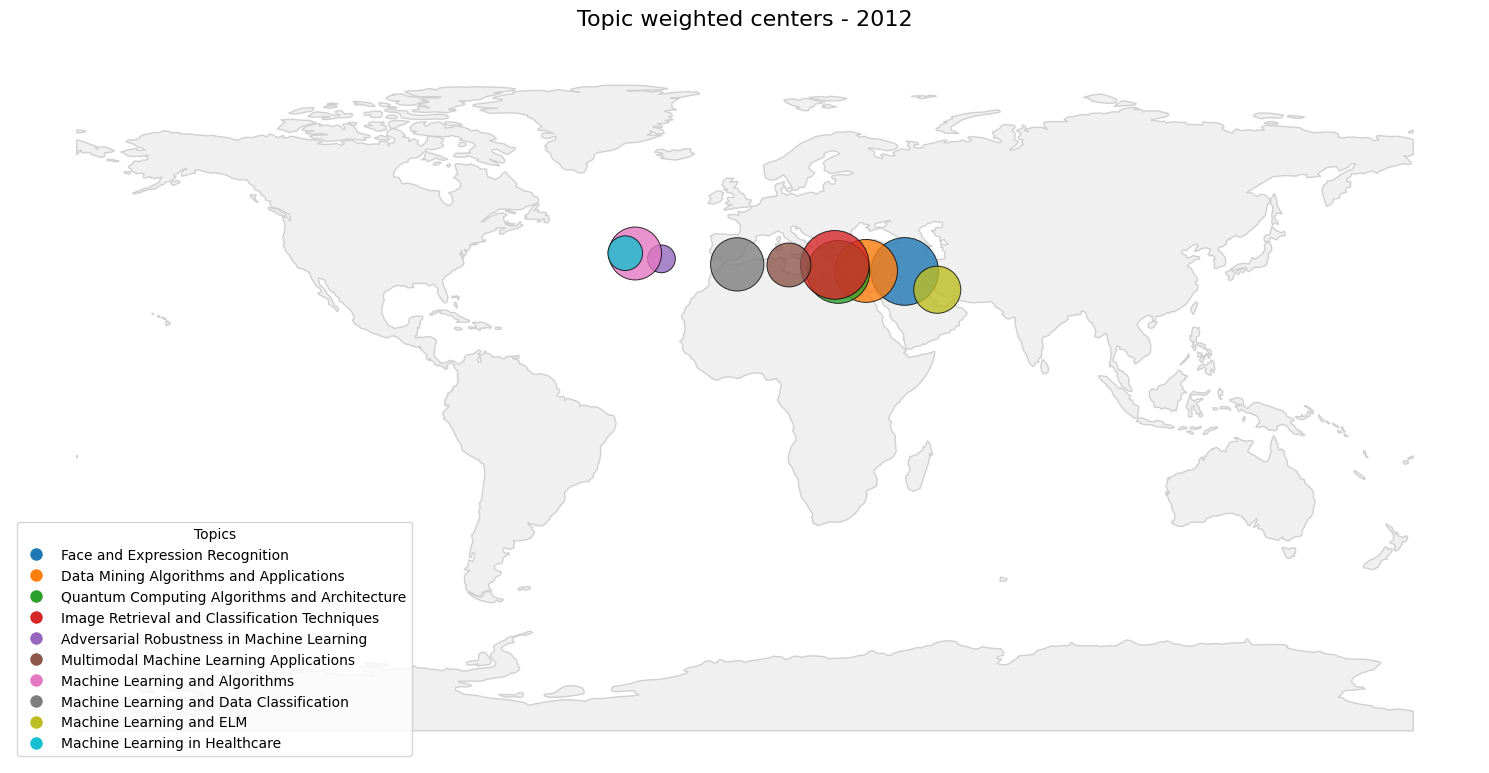

In 2013:
	Face and Expression Recognition had 596 works published by 92 research hubs
	Data Mining Algorithms and Applications had 274 works published by 83 research hubs
	Quantum Computing Algorithms and Architecture had 646 works published by 91 research hubs
	Image Retrieval and Classification Techniques had 555 works published by 99 research hubs
	Adversarial Robustness in Machine Learning had 51 works published by 23 research hubs
	Multimodal Machine Learning Applications had 199 works published by 52 research hubs
	Machine Learning and Algorithms had 330 works published by 74 research hubs
	Machine Learning and Data Classification had 227 works published by 64 research hubs
	Machine Learning and ELM had 191 works published by 46 research hubs
	Machine Learning in Healthcare had 95 works published by 30 research hubs


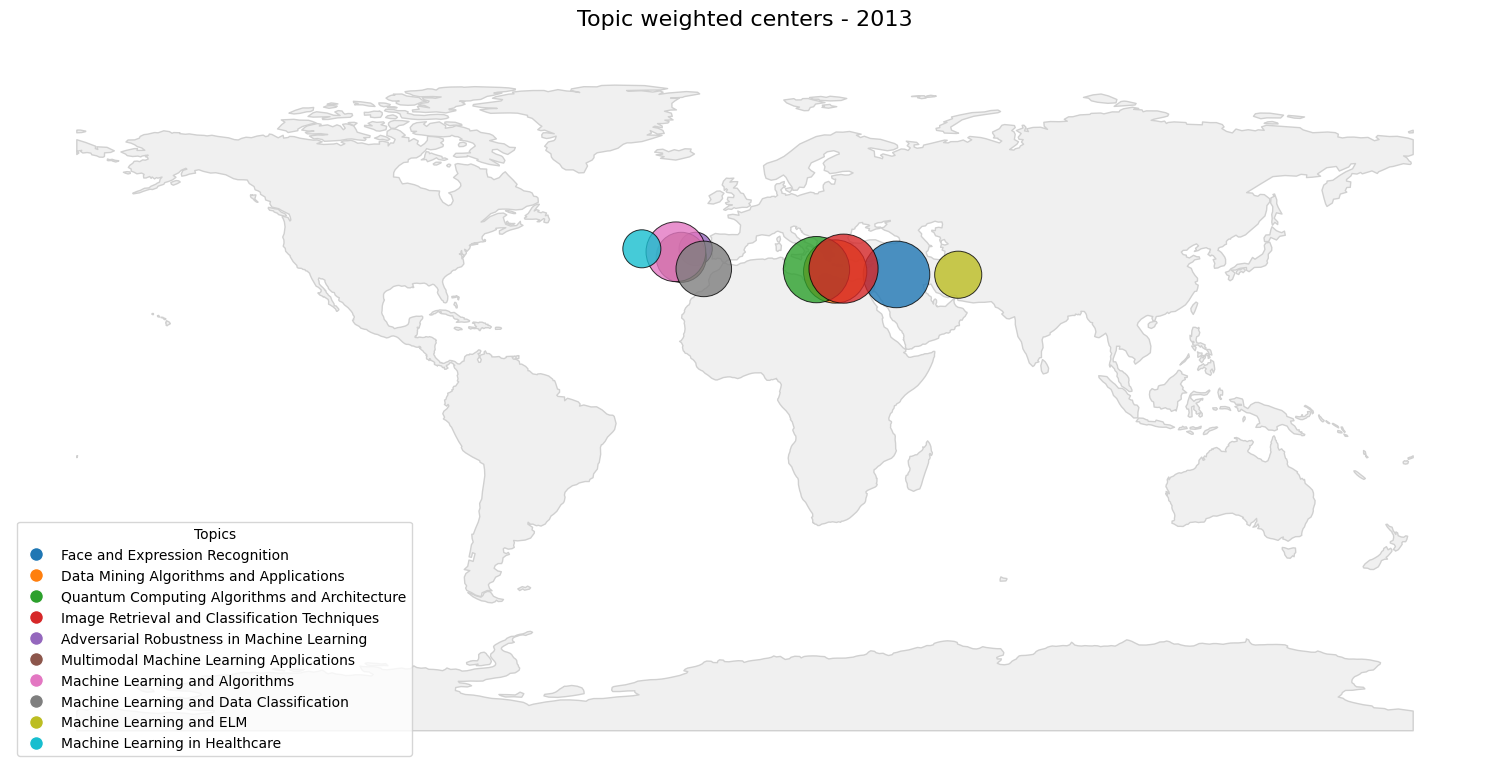

In 2014:
	Face and Expression Recognition had 572 works published by 98 research hubs
	Data Mining Algorithms and Applications had 288 works published by 85 research hubs
	Quantum Computing Algorithms and Architecture had 710 works published by 87 research hubs
	Image Retrieval and Classification Techniques had 564 works published by 101 research hubs
	Adversarial Robustness in Machine Learning had 54 works published by 22 research hubs
	Multimodal Machine Learning Applications had 263 works published by 54 research hubs
	Machine Learning and Algorithms had 240 works published by 59 research hubs
	Machine Learning and Data Classification had 227 works published by 64 research hubs
	Machine Learning and ELM had 182 works published by 57 research hubs
	Machine Learning in Healthcare had 126 works published by 47 research hubs


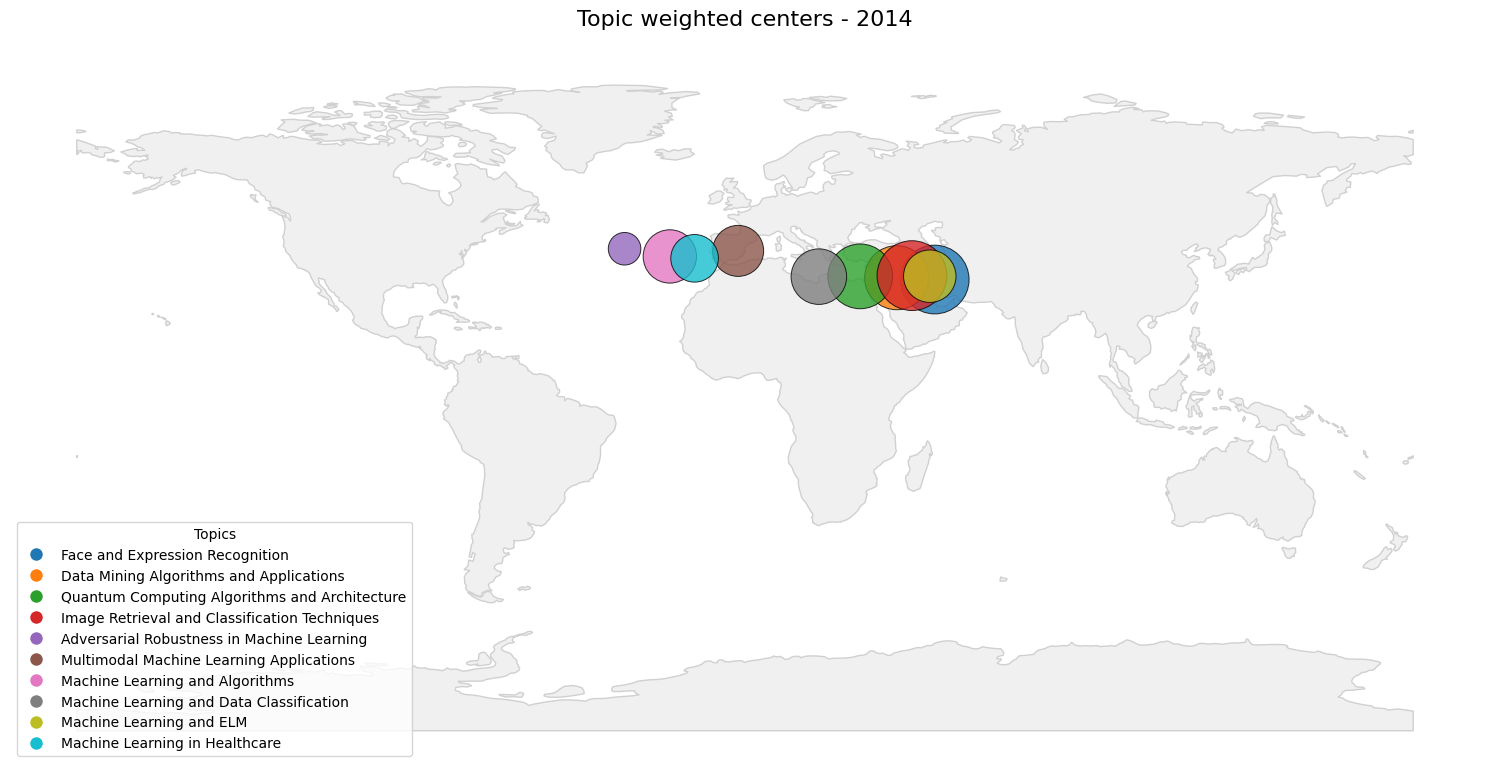

In 2015:
	Face and Expression Recognition had 721 works published by 95 research hubs
	Data Mining Algorithms and Applications had 270 works published by 81 research hubs
	Quantum Computing Algorithms and Architecture had 682 works published by 89 research hubs
	Image Retrieval and Classification Techniques had 540 works published by 93 research hubs
	Adversarial Robustness in Machine Learning had 106 works published by 37 research hubs
	Multimodal Machine Learning Applications had 420 works published by 64 research hubs
	Machine Learning and Algorithms had 303 works published by 59 research hubs
	Machine Learning and Data Classification had 326 works published by 79 research hubs
	Machine Learning and ELM had 274 works published by 64 research hubs
	Machine Learning in Healthcare had 154 works published by 43 research hubs


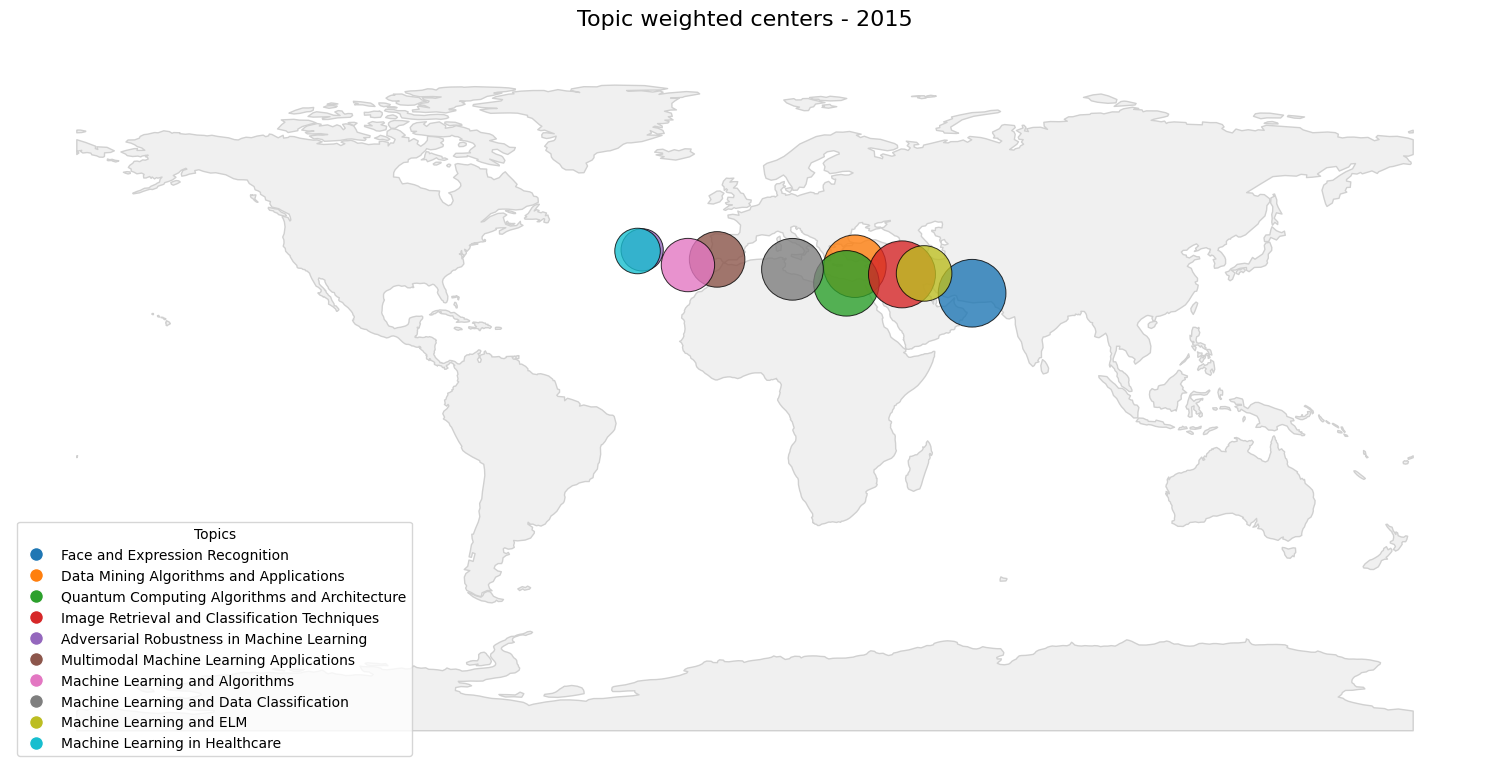

In 2016:
	Face and Expression Recognition had 647 works published by 87 research hubs
	Data Mining Algorithms and Applications had 263 works published by 73 research hubs
	Quantum Computing Algorithms and Architecture had 695 works published by 84 research hubs
	Image Retrieval and Classification Techniques had 563 works published by 92 research hubs
	Adversarial Robustness in Machine Learning had 213 works published by 45 research hubs
	Multimodal Machine Learning Applications had 623 works published by 80 research hubs
	Machine Learning and Algorithms had 235 works published by 61 research hubs
	Machine Learning and Data Classification had 348 works published by 87 research hubs
	Machine Learning and ELM had 260 works published by 66 research hubs
	Machine Learning in Healthcare had 217 works published by 54 research hubs


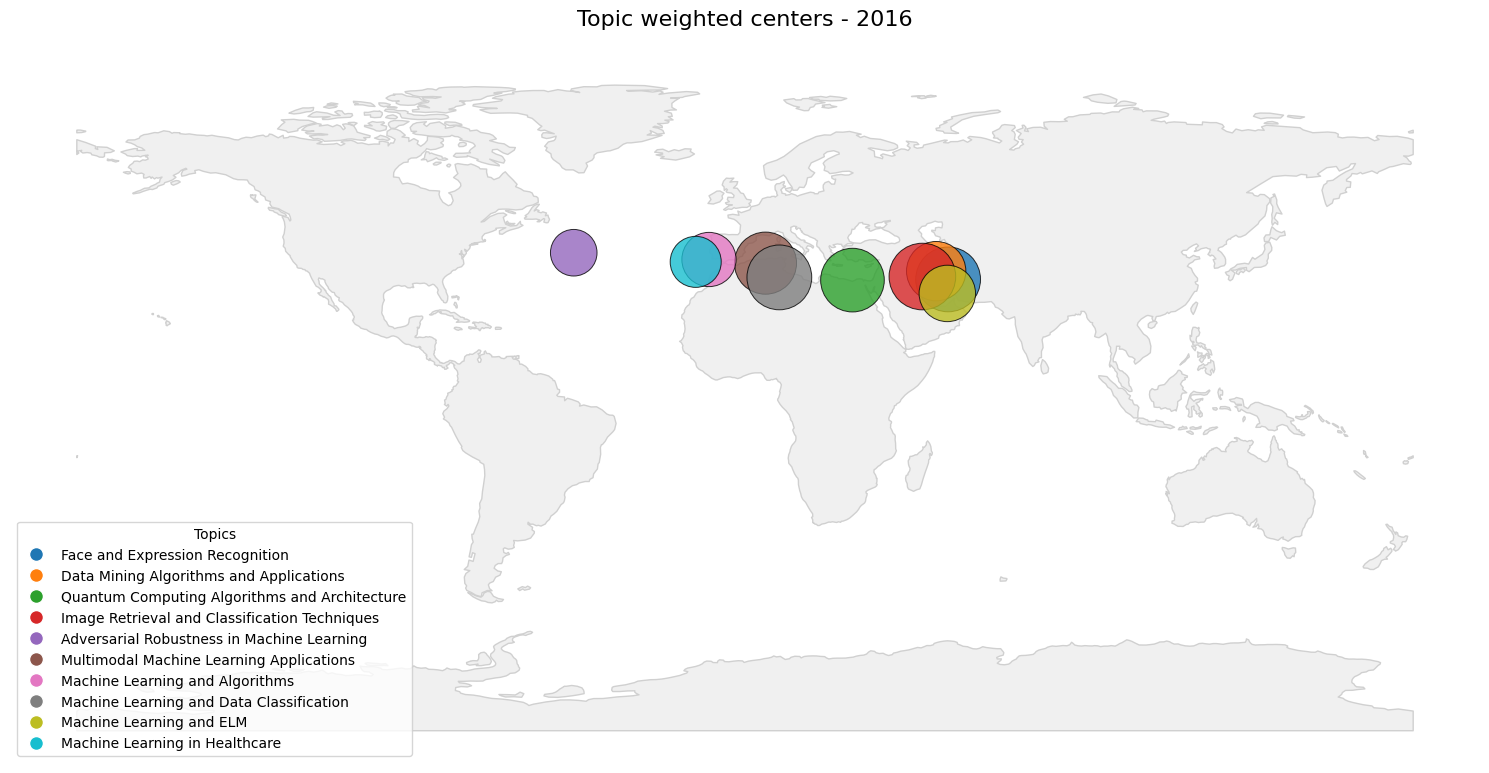

In 2017:
	Face and Expression Recognition had 786 works published by 103 research hubs
	Data Mining Algorithms and Applications had 225 works published by 72 research hubs
	Quantum Computing Algorithms and Architecture had 775 works published by 86 research hubs
	Image Retrieval and Classification Techniques had 490 works published by 84 research hubs
	Adversarial Robustness in Machine Learning had 384 works published by 59 research hubs
	Multimodal Machine Learning Applications had 931 works published by 85 research hubs
	Machine Learning and Algorithms had 283 works published by 59 research hubs
	Machine Learning and Data Classification had 403 works published by 79 research hubs
	Machine Learning and ELM had 389 works published by 78 research hubs
	Machine Learning in Healthcare had 244 works published by 61 research hubs


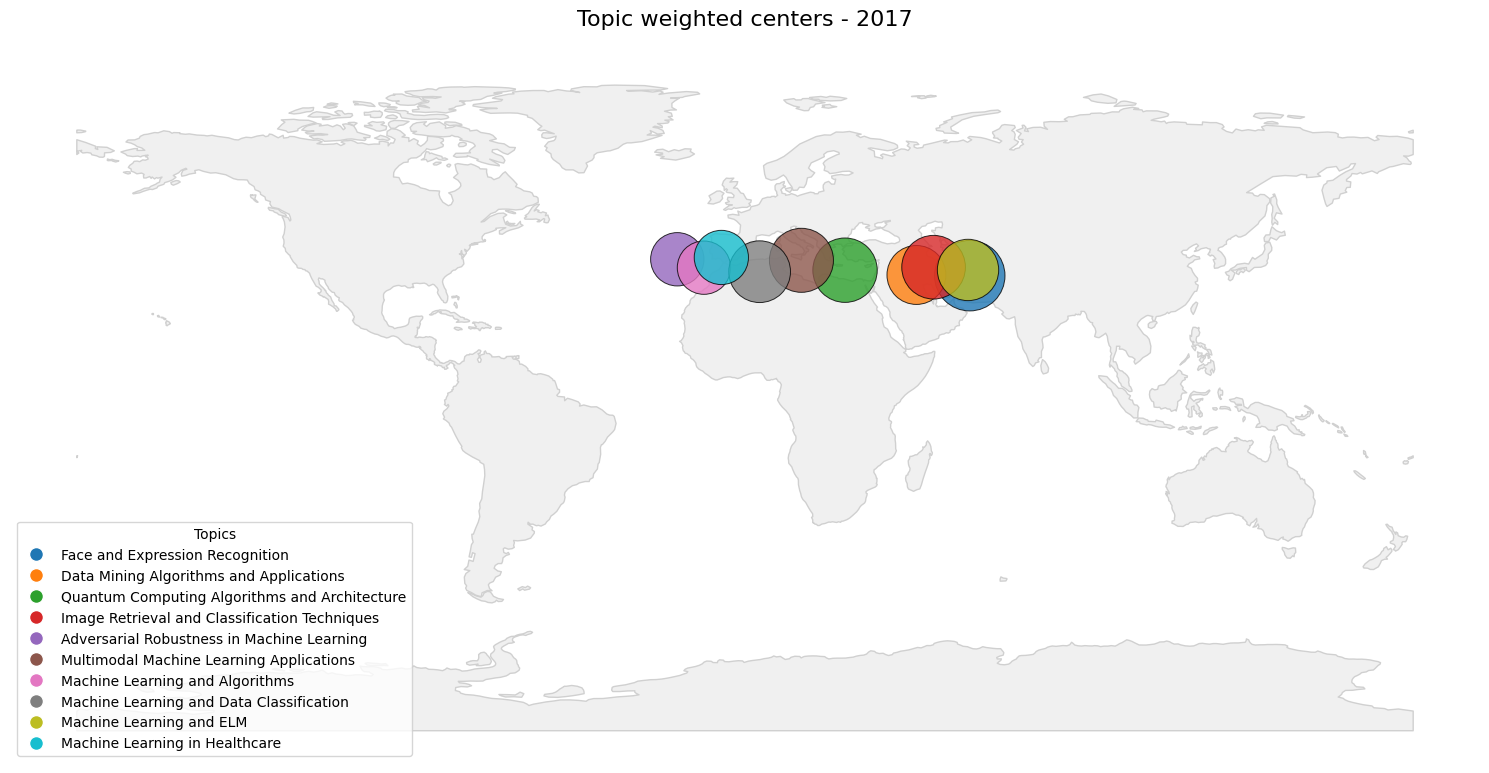

In 2018:
	Face and Expression Recognition had 619 works published by 88 research hubs
	Data Mining Algorithms and Applications had 213 works published by 73 research hubs
	Quantum Computing Algorithms and Architecture had 811 works published by 91 research hubs
	Image Retrieval and Classification Techniques had 355 works published by 76 research hubs
	Adversarial Robustness in Machine Learning had 680 works published by 80 research hubs
	Multimodal Machine Learning Applications had 1101 works published by 95 research hubs
	Machine Learning and Algorithms had 258 works published by 62 research hubs
	Machine Learning and Data Classification had 431 works published by 85 research hubs
	Machine Learning and ELM had 404 works published by 79 research hubs
	Machine Learning in Healthcare had 385 works published by 72 research hubs


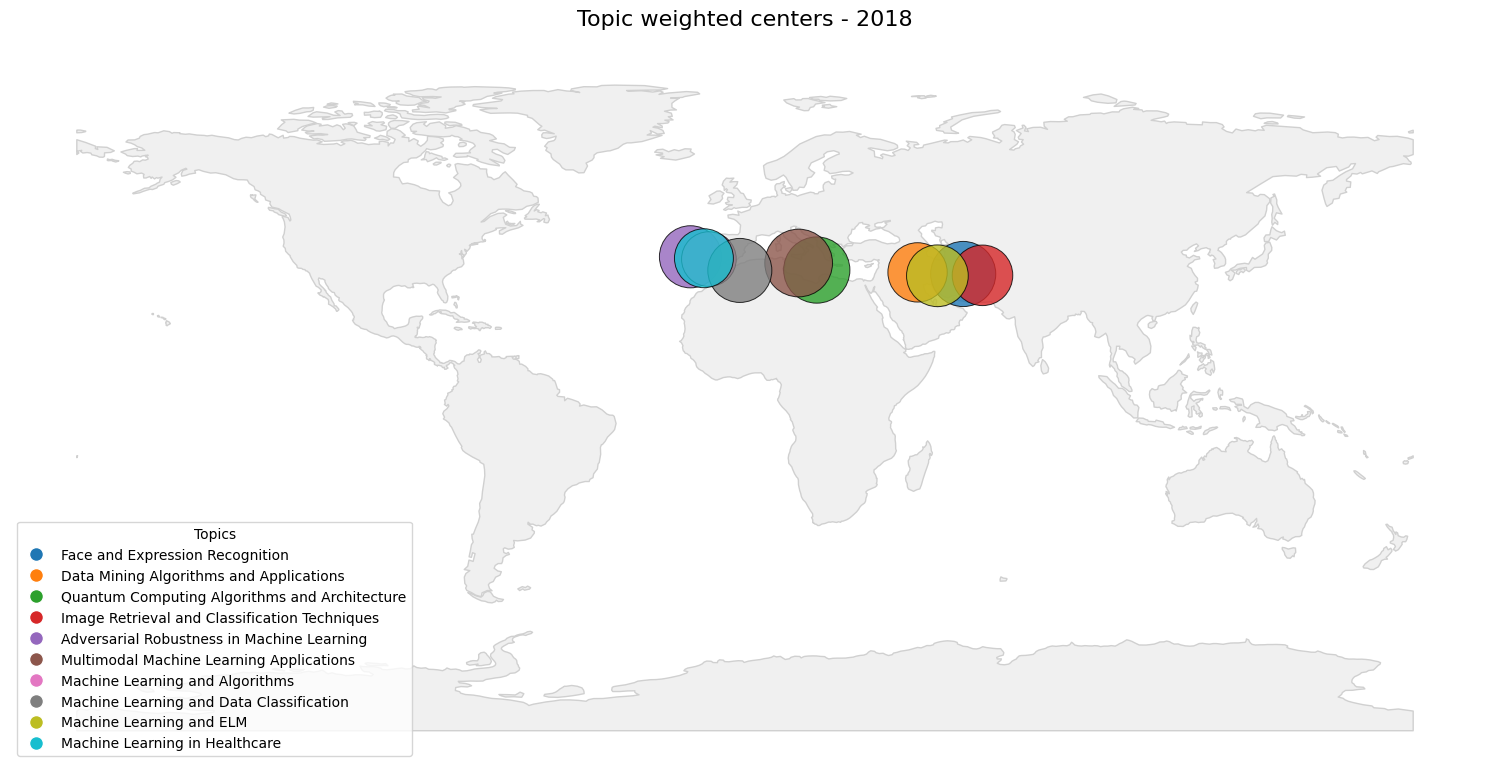

In 2019:
	Face and Expression Recognition had 602 works published by 88 research hubs
	Data Mining Algorithms and Applications had 189 works published by 56 research hubs
	Quantum Computing Algorithms and Architecture had 918 works published by 84 research hubs
	Image Retrieval and Classification Techniques had 369 works published by 73 research hubs
	Adversarial Robustness in Machine Learning had 849 works published by 95 research hubs
	Multimodal Machine Learning Applications had 1363 works published by 96 research hubs
	Machine Learning and Algorithms had 262 works published by 66 research hubs
	Machine Learning and Data Classification had 520 works published by 105 research hubs
	Machine Learning and ELM had 472 works published by 85 research hubs
	Machine Learning in Healthcare had 626 works published by 94 research hubs


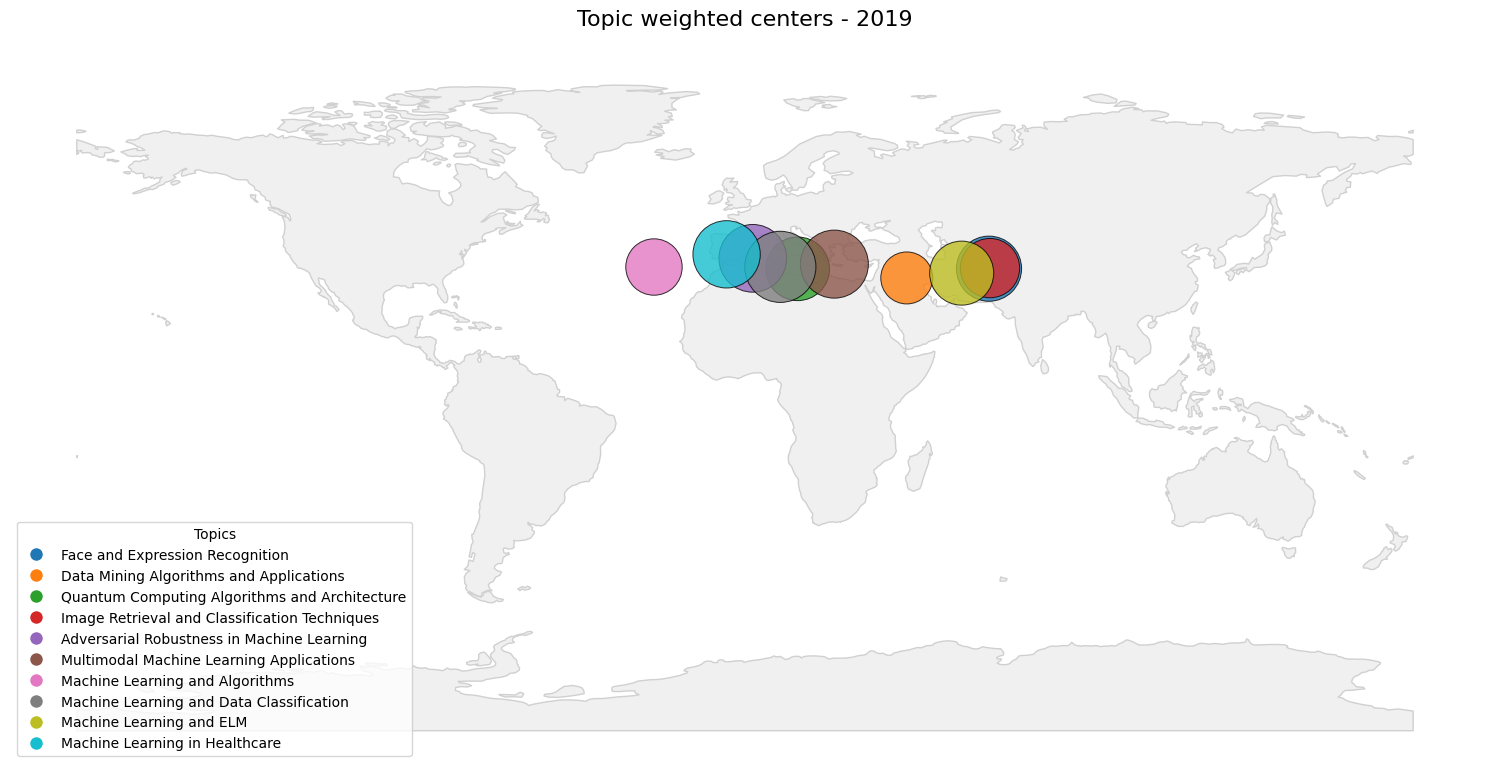

In [35]:
# Assign colors to the topics
cmap = plt.get_cmap('tab10')
topic_colors = {topic: cmap(i) for i, topic in enumerate(topic_ids)}

for year in all_topics_all_year_centers:
    topics_list = all_topics_all_year_centers[year]
    print(f"In {year}:")
    for topic in topics_list:
        print(f"\t{machine_learning_topics[topic[0]]} had {topic[4]} works published by {topic[3]} research hubs")
    # Convert the list of topic_tupples into a df
    topic_map_df = pd.DataFrame(topics_list, columns=['topic_id', 'centroid_lat', 'centroid_long', 'num_hubs', 'total_num_works'])
    # Add the topic colors
    topic_map_df['color'] = topic_map_df['topic_id'].map(topic_colors)
    # Plot the topic centers
    plot_topics_centers_for_year(topic_map_df)
    